# 관세청 수출 10일 잠정치 — 품목별 조회 · 예측 빈티지 비교 (`korea_export_10day_flash_query_v1`)

`korea_export_10day_flash_v8.ipynb`가 저장한 DB 테이블을 **조회/분석 전용**으로 사용하는 노트북 (수집/예측 없음).

| 기능 | 셀 |
|---|---|
| ① 품목 최대 10개 입력 → 실적+최신 예측 조회 및 시각화 | §5 |
| ② 시계열 예측 수행일(`forecast_date` 빈티지) 조회 | §4 |
| ③ 예측일 2개 입력 → 예측치 변화/차이 분석 | §6 |

**표시 규칙**: 실제치 = **실선**, 예측치 = **점선**. 단위: 백만 달러 / 10일 구간 (DB 원본은 천 달러 → /1000).

**사용 테이블**
- 실적: `korea_export_10day_flash_by_item` (stat_date, item_name, exp_dlr_inc)
- 예측: `korea_export_10day_flash_by_item_forecast_10d` (forecast_date 빈티지, target_date, model, exp_dlr)


## 1. 사용자 입력 변수 (이 셀만 수정)

In [1]:
# ==================== 사용자 입력 변수 (필요 시 여기만 수정) ====================

# --- ① 조회 품목 (최대 10개) --------------------------------------------------
# None 이면 DB의 전체 품목 자동 사용 ("전체" 포함 최대 10개까지)
# 품목명은 §4-2 "DB 품목 목록" 출력에서 복사 (예: 전체, 반도체, 철강제품, 승용차, ...)
ITEMS = None
# ITEMS = ["반도체", "승용차", "석유제품", "선박", "무선통신기기",
#          "자동차부품", "철강제품", "컴퓨터주변기기", "정밀기기", "가전제품"]

# --- ③ 예측 빈티지 비교: 예측 수행일 2개 --------------------------------------
# None 이면 DB의 최신 2개 forecast_date 자동 선택 (A=이전, B=최신)
# 직접 지정 시 "YYYY-MM-DD" 문자열 — 사용 가능한 날짜는 §4-1 조회 결과 참고
FORECAST_DATE_A = None          # 비교 기준(이전) 예측일  예: "2026-07-01"
FORECAST_DATE_B = None          # 비교 대상(최신) 예측일  예: "2026-07-11"

# --- 공통 옵션 -----------------------------------------------------------------
MODEL           = "ENSEMBLE"    # 비교/표시 기준 모델: SARIMA / ETS / THETA / ENSEMBLE
PLOT_YEARS_BACK = 3             # 개별 차트에 표시할 과거 연수
OVERVIEW_MONTHS = 12            # 그리드 개요 차트에 표시할 과거 개월 수
SHOW_ALL_MODELS = False         # True면 개별 차트에 SARIMA/ETS/THETA도 점선으로 함께 표시

# --- DB 테이블 (v8 수집 노트북과 동일 — 변경 금지) ------------------------------
ACTUAL_TABLE   = "korea_export_10day_flash_by_item"
FORECAST_TABLE = "korea_export_10day_flash_by_item_forecast_10d"

MAX_ITEMS = 10                  # 품목 입력 상한


## 2. 경로 설정 (노트북 / 데스크탑 공용)

In [2]:
import sys
import os
from pathlib import Path

# 두 PC의 알려진 DATA 폴더 경로 (fallback용)
KNOWN_DATA_PATHS = [
    r"C:\Users\Hoyoung_Park\PyCharmMiscProject\stock_forecast\DATA",
    r"C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy\DATA",
]

def setup_universal_paths():
    """어떤 PC에서도 작동하는 범용 경로 설정: DATA 폴더 자동 탐색 + 고정 경로 fallback"""
    current = Path.cwd()
    # 1) 현재 위치 기준 상위 폴더 자동 탐색
    for parent in [current, *current.parents]:
        data_folder = parent / "DATA"
        if data_folder.exists():
            for p in (str(parent), str(data_folder)):
                if p not in sys.path:
                    sys.path.insert(0, p)
            print(f"[경로 설정] 자동 탐색 성공 | 프로젝트 루트: {parent}")
            print(f"[경로 설정] DATA 폴더: {data_folder}")
            return str(data_folder)
    # 2) 고정 경로 fallback
    for dp in KNOWN_DATA_PATHS:
        if os.path.exists(dp):
            root = str(Path(dp).parent)
            for p in (root, dp):
                if p not in sys.path:
                    sys.path.insert(0, p)
            print(f"[경로 설정] 고정 경로 사용 | 프로젝트 루트: {root}")
            print(f"[경로 설정] DATA 폴더: {dp}")
            return dp
    raise FileNotFoundError(
        f"DATA 폴더를 찾을 수 없습니다.\n현재 위치: {current}\n"
        f"상위 폴더에 DATA 폴더가 있는지, 또는 KNOWN_DATA_PATHS의 경로가 맞는지 확인하세요."
    )

DATA_PATH = setup_universal_paths()


[경로 설정] 자동 탐색 성공 | 프로젝트 루트: C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy
[경로 설정] DATA 폴더: C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy\DATA


## 3. Import 및 DB 연결

In [3]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# 한글 폰트 (Windows)
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# ── 기존 공용 함수 (수정 금지 모듈) — star import를 "먼저" 수행 (v8 규약 동일) ──
from DATA.stock_invest_function import *  # get_db_host 등

# ── 핵심 이름 확정 import (동명 shadowing 방지: datetime/date/text 등) ─────────
from datetime import date, datetime, timedelta
from typing import Optional, List
from sqlalchemy import create_engine, text

DB_INFO = {
    "host": get_db_host(),
    "port": 3307,
    "user": "stox7412",
    "password": "Apt106503!~",
    "database": "investar",
}

def get_engine_from_info(db_info: dict):
    url = (f"mysql+pymysql://{db_info['user']}:{db_info['password']}"
           f"@{db_info['host']}:{db_info['port']}/{db_info['database']}?charset=utf8mb4")
    return create_engine(url, pool_recycle=3600)

engine = get_engine_from_info(DB_INFO)
with engine.connect() as conn:
    conn.execute(text("SELECT 1"))
print("DB 연결 성공")


DB 연결 성공


## 4. 조회 유틸: 예측 수행일(빈티지) · DB 품목 목록

### 4-1. 시계열 예측 수행일 조회 — `list_forecast_dates()`
저장된 모든 `forecast_date` 빈티지와 각 빈티지의 품목 수·모델·예측 대상 구간을 요약합니다.
§6 비교에 사용할 두 날짜는 이 목록에서 선택하세요.

In [4]:
def list_forecast_dates(item_name: Optional[str] = None,
                        model: Optional[str] = None) -> pd.DataFrame:
    """
    시계열 예측을 수행한 날짜(forecast_date 빈티지) 목록 조회.
      - item_name 지정 시 해당 품목이 포함된 빈티지만
      - model 지정 시 해당 모델이 포함된 빈티지만
    반환: [forecast_date, 품목수, 모델, 예측시작, 예측종료, 행수]
    """
    where, params = [], {}
    if item_name:
        where.append("item_name = :item"); params["item"] = item_name
    if model:
        where.append("model = :model"); params["model"] = model
    where_sql = ("WHERE " + " AND ".join(where)) if where else ""

    q = text(f"""
        SELECT forecast_date,
               COUNT(DISTINCT item_name)                    AS 품목수,
               GROUP_CONCAT(DISTINCT model ORDER BY model)  AS 모델,
               MIN(target_date)                             AS 예측시작,
               MAX(target_date)                             AS 예측종료,
               COUNT(*)                                     AS 행수
        FROM {FORECAST_TABLE}
        {where_sql}
        GROUP BY forecast_date
        ORDER BY forecast_date DESC
    """)
    df = pd.read_sql(q, engine, params=params)
    if df.empty:
        print("저장된 예측이 없습니다. v8 수집 노트북에서 RUN_FORECAST=True로 먼저 실행하세요.")
    return df

# ---- 실행: 전체 빈티지 목록 ----
df_vintages = list_forecast_dates()
print(f"저장된 예측 빈티지: {len(df_vintages)}개")
df_vintages


저장된 예측 빈티지: 1개


,forecast_date,품목수,모델,예측시작,예측종료,행수
0,2026-07-15,11,"ENSEMBLE,ETS,SARIMA,THETA",2026-07-20,2026-11-10,528


### 4-2. DB 품목 목록 및 조회 대상 확정 (최대 10개)

In [5]:
def get_db_items() -> List[str]:
    """실적 테이블의 전체 품목 목록 ('전체'를 맨 앞으로 정렬)"""
    items = pd.read_sql(
        text(f"SELECT DISTINCT item_name FROM {ACTUAL_TABLE} ORDER BY item_name"),
        engine)["item_name"].tolist()
    items.sort(key=lambda x: (0 if ("전체" in x or "총" in x) else 1, x))
    return items

def resolve_items(items_input) -> List[str]:
    """ITEMS 입력 검증: None→DB 전체(최대 MAX_ITEMS), 리스트→존재 검증 + 상한 절단"""
    db_items = get_db_items()
    if items_input is None:
        sel = db_items[:MAX_ITEMS]
    else:
        missing = [x for x in items_input if x not in db_items]
        if missing:
            raise ValueError(f"DB에 없는 품목: {missing}\n사용 가능 품목: {db_items}")
        sel = list(dict.fromkeys(items_input))          # 중복 제거(순서 유지)
        if len(sel) > MAX_ITEMS:
            print(f"[주의] 품목 {len(sel)}개 입력 → 앞 {MAX_ITEMS}개만 사용")
            sel = sel[:MAX_ITEMS]
    return sel

DB_ITEMS = get_db_items()
print(f"DB 품목 목록 ({len(DB_ITEMS)}개): {DB_ITEMS}")

SELECTED_ITEMS = resolve_items(ITEMS)
print(f"\n조회 대상 품목 ({len(SELECTED_ITEMS)}개): {SELECTED_ITEMS}")


DB 품목 목록 (11개): ['전체', '가전제품', '무선통신기기', '반도체', '석유제품', '선박', '승용차', '자동차부품', '정밀기기', '철강제품', '컴퓨터주변기기']

조회 대상 품목 (10개): ['전체', '가전제품', '무선통신기기', '반도체', '석유제품', '선박', '승용차', '자동차부품', '정밀기기', '철강제품']


## 5. ① 품목별 조회 및 분석 시각화

- **실제치 = 검은 실선**, **예측치 = 점선** (최신 빈티지 기준)
- 5-1: 전체 품목 그리드 개요 → 5-2: 품목별 상세 차트 → 5-3: 분석 요약표

In [6]:
def load_actual_series(item_name: str) -> pd.Series:
    """실적(10일 구간 증분) 시계열 로드 — 단위: 천 달러"""
    q = text(f"""
        SELECT stat_date, exp_dlr_inc
        FROM {ACTUAL_TABLE}
        WHERE item_name = :item
        ORDER BY stat_date
    """)
    df = pd.read_sql(q, engine, params={"item": item_name})
    if df.empty:
        return pd.Series(dtype=float)
    return pd.Series(df["exp_dlr_inc"].values.astype(float),
                     index=pd.DatetimeIndex(pd.to_datetime(df["stat_date"])))

def load_forecast(item_name: str, forecast_date, model: Optional[str] = None) -> pd.DataFrame:
    """특정 빈티지의 예측 로드 — [target_date, model, exp_dlr]"""
    where_model = "AND model = :model" if model else ""
    q = text(f"""
        SELECT target_date, model, exp_dlr
        FROM {FORECAST_TABLE}
        WHERE item_name = :item AND forecast_date = :fd {where_model}
        ORDER BY target_date, model
    """)
    params = {"item": item_name, "fd": forecast_date}
    if model:
        params["model"] = model
    df = pd.read_sql(q, engine, params=params)
    if not df.empty:
        df["target_date"] = pd.to_datetime(df["target_date"])
    return df

def latest_forecast_date(item_name: Optional[str] = None):
    """최신 forecast_date (품목 지정 시 해당 품목 기준)"""
    where = "WHERE item_name = :item" if item_name else ""
    params = {"item": item_name} if item_name else {}
    v = pd.read_sql(text(f"SELECT MAX(forecast_date) AS fd FROM {FORECAST_TABLE} {where}"),
                    engine, params=params)["fd"].iloc[0]
    return pd.to_datetime(v).date() if v is not None else None


### 5-1. 전체 품목 그리드 개요 (실적 실선 + 최신 예측 점선)

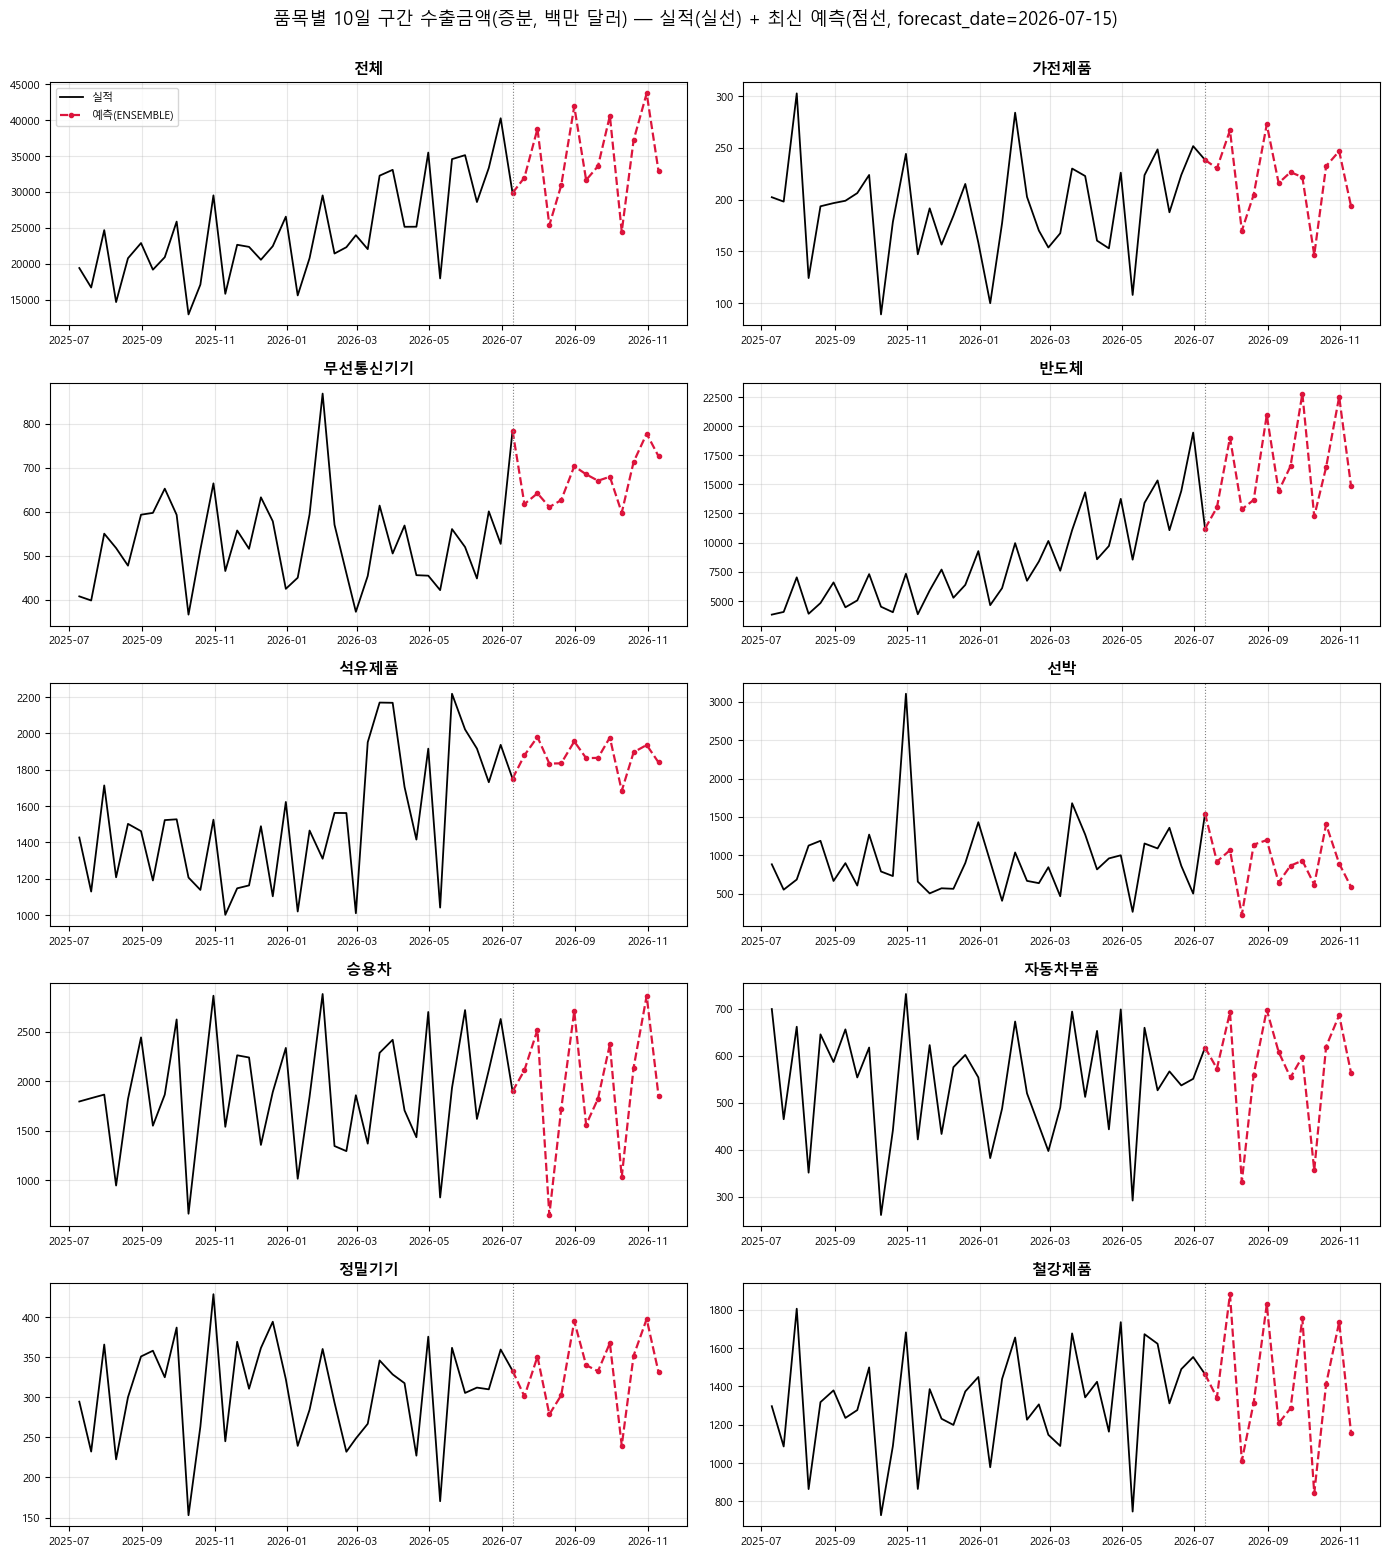

In [7]:
def plot_items_overview(items: List[str], months_back: int = OVERVIEW_MONTHS,
                        model: str = MODEL):
    """품목 최대 10개를 그리드 subplot으로 한눈에 — 실적 실선 / 예측 점선"""
    items = items[:MAX_ITEMS]
    n = len(items)
    ncols = 2
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.1 * nrows), squeeze=False)

    fd_latest = latest_forecast_date()
    for k, item in enumerate(items):
        ax = axes[k // ncols][k % ncols]
        s = load_actual_series(item)
        if s.empty:
            ax.set_title(f"{item} (실적 없음)"); ax.axis("off"); continue
        s_plot = s[s.index >= s.index[-1] - pd.DateOffset(months=months_back)]
        # 실제치: 실선
        ax.plot(s_plot.index, s_plot.values / 1000, color="black", lw=1.3,
                label="실적")
        # 예측치: 점선 (실적 마지막 점과 연결)
        fdf = load_forecast(item, fd_latest, model=model) if fd_latest else pd.DataFrame()
        if not fdf.empty:
            x = [s.index[-1]] + list(fdf["target_date"])
            y = [s.values[-1] / 1000] + list(fdf["exp_dlr"] / 1000)
            ax.plot(x, y, color="crimson", lw=1.6, ls="--", marker="o", ms=3,
                    label=f"예측({model})")
            ax.axvline(s.index[-1], color="gray", ls=":", lw=0.8)
        ax.set_title(item, fontsize=11, fontweight="bold")
        ax.grid(alpha=0.3)
        ax.tick_params(labelsize=8)
        if k == 0:
            ax.legend(fontsize=8, loc="upper left")
    # 빈 subplot 숨김
    for k in range(n, nrows * ncols):
        axes[k // ncols][k % ncols].axis("off")
    fig.suptitle(f"품목별 10일 구간 수출금액(증분, 백만 달러) — 실적(실선) + 최신 예측(점선, "
                 f"forecast_date={fd_latest})", fontsize=13, y=1.002)
    plt.tight_layout()
    plt.show()

plot_items_overview(SELECTED_ITEMS)


### 5-2. 품목별 상세 차트

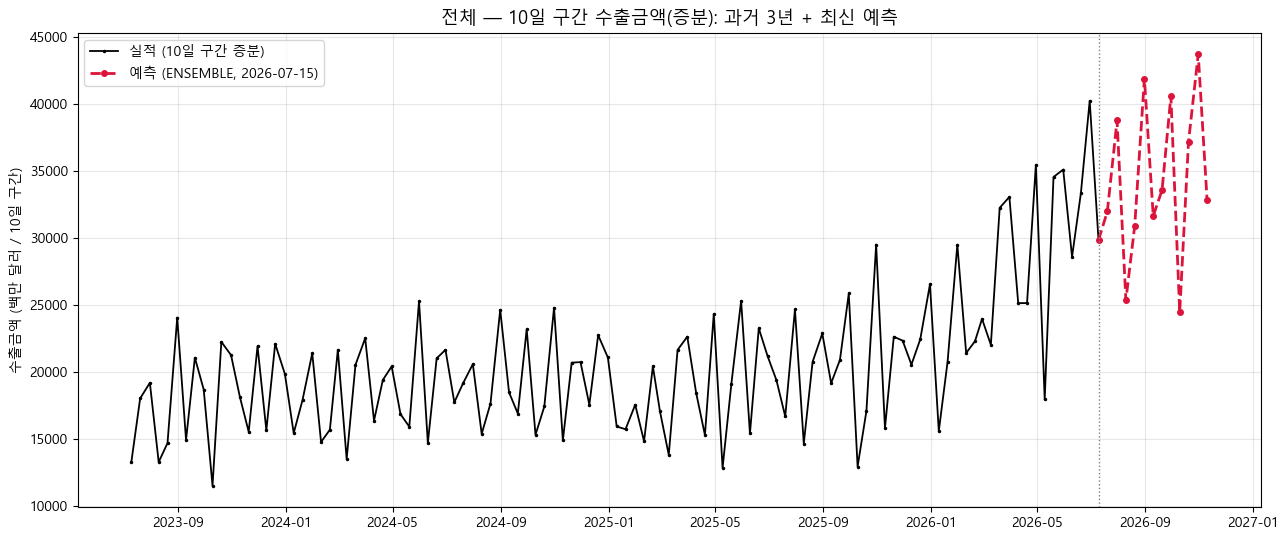

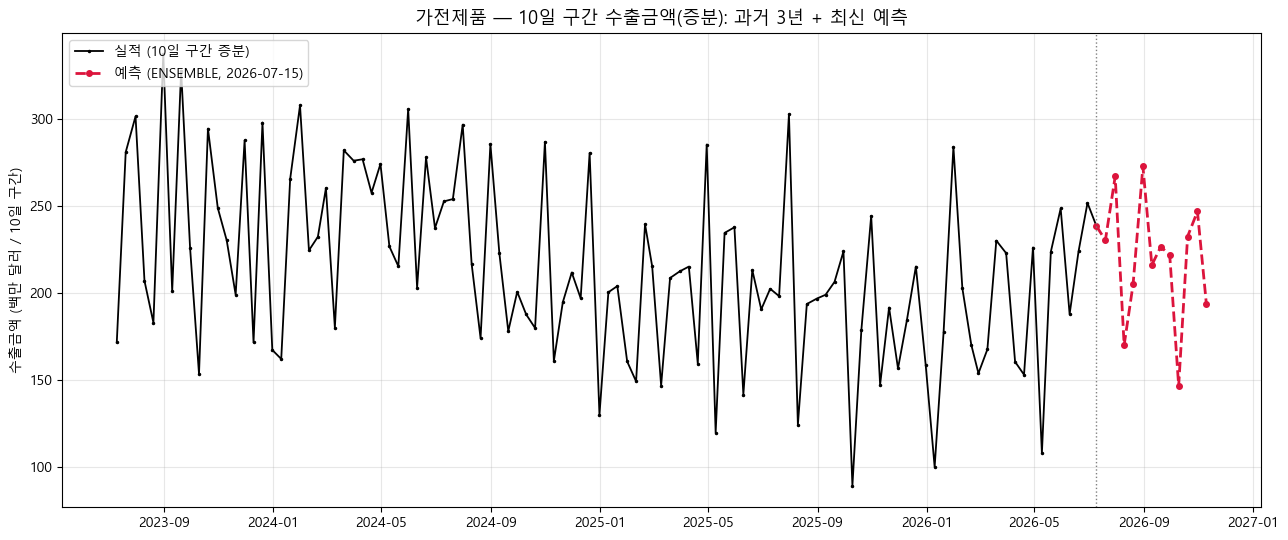

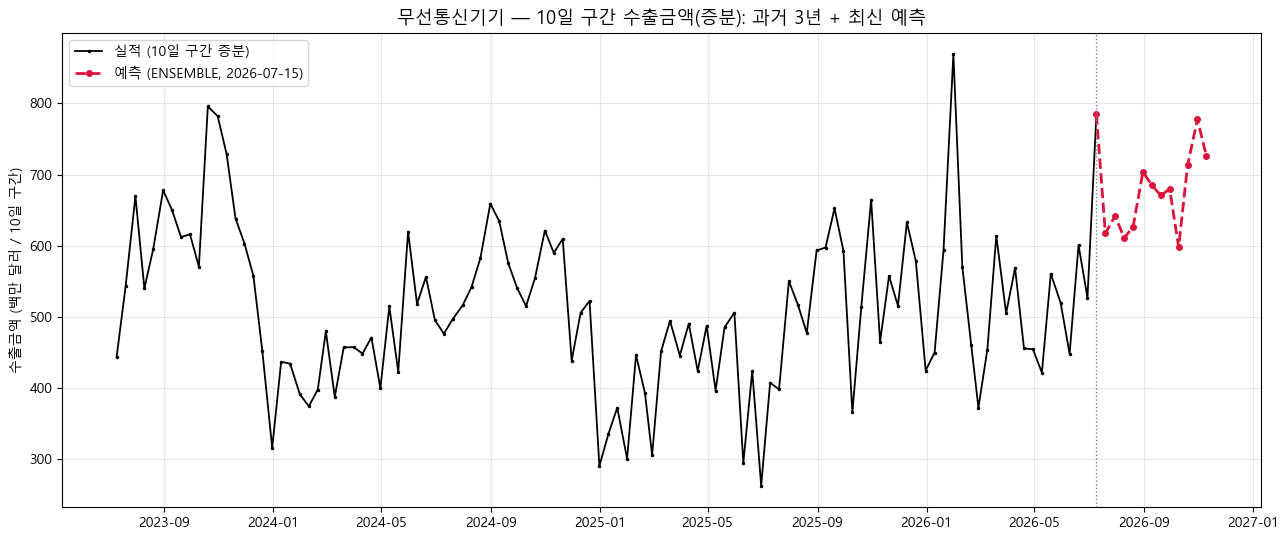

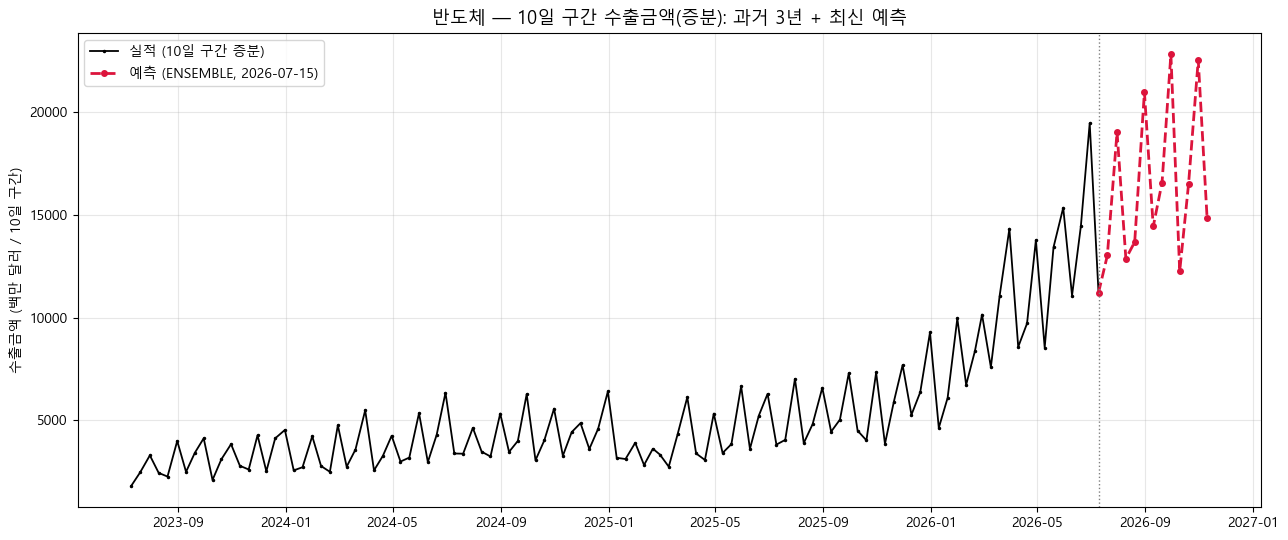

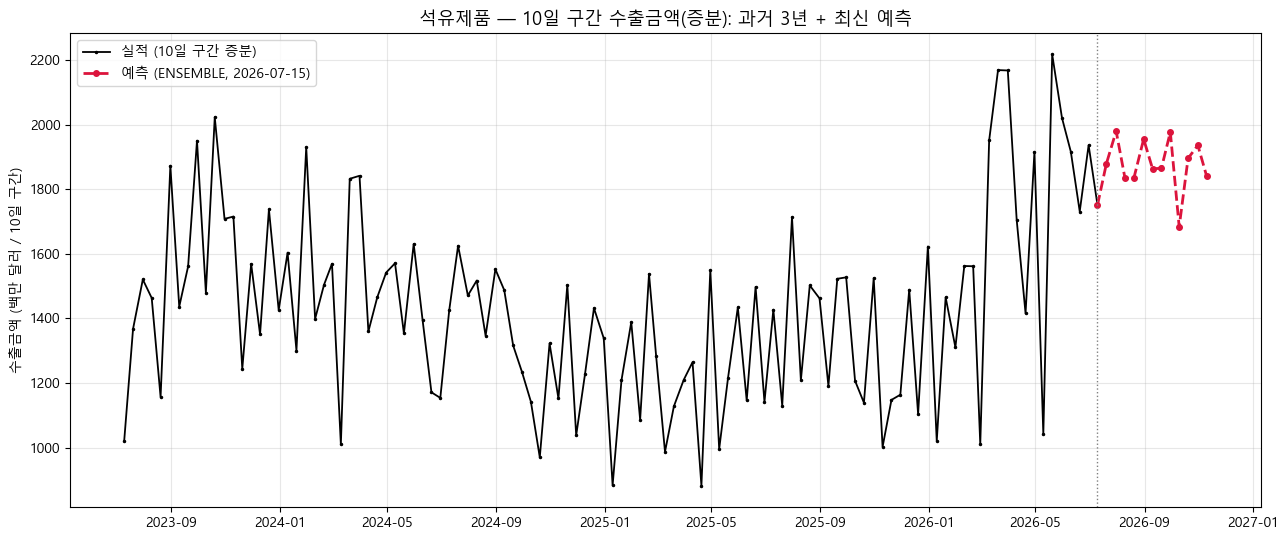

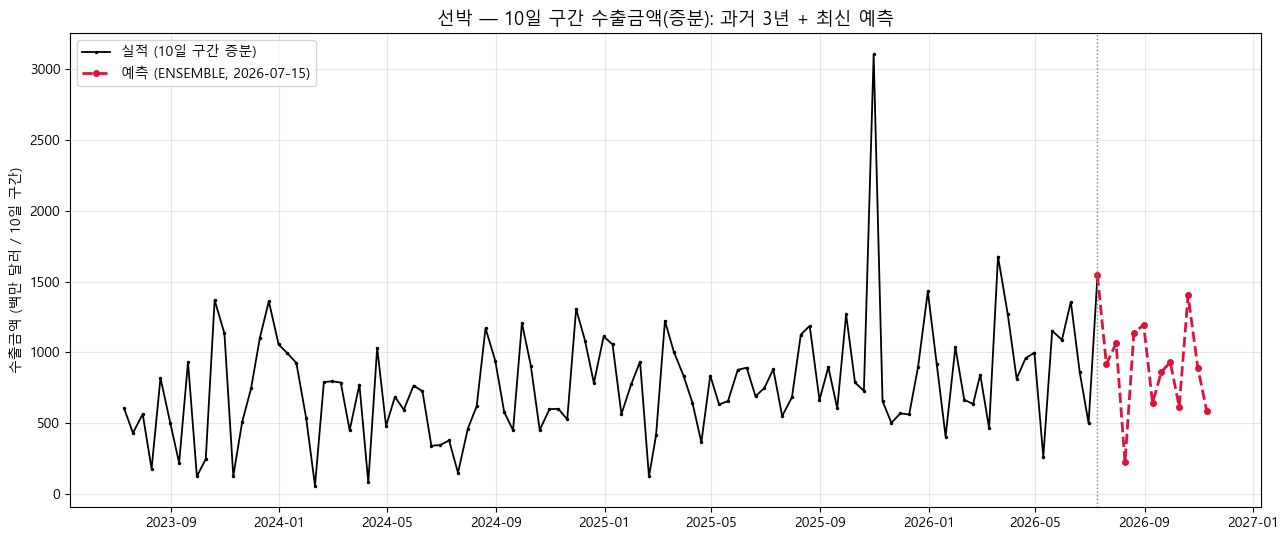

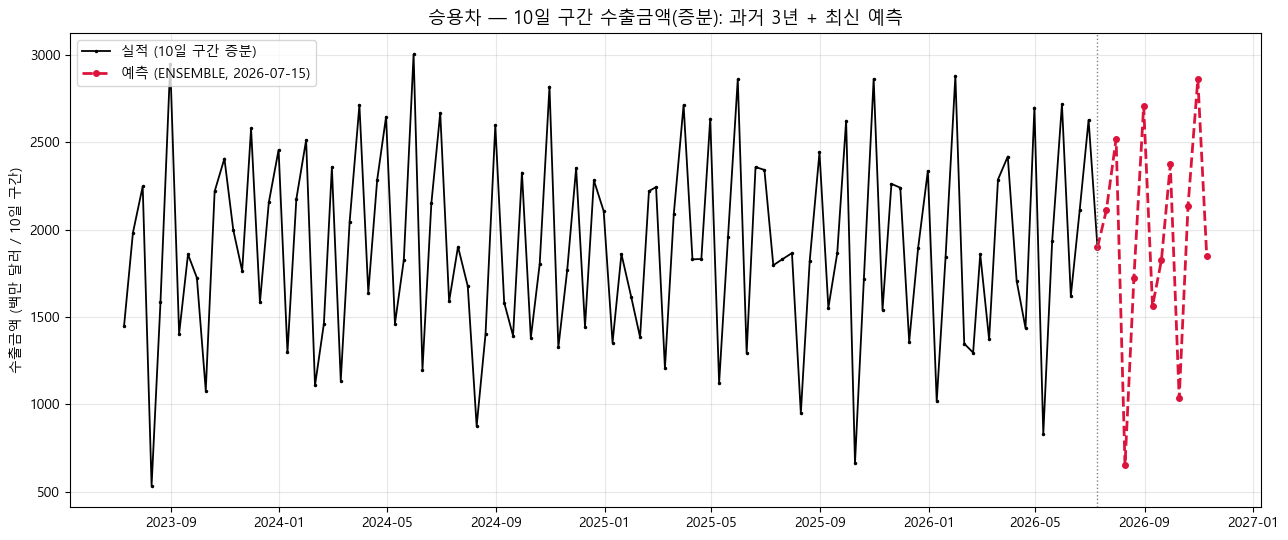

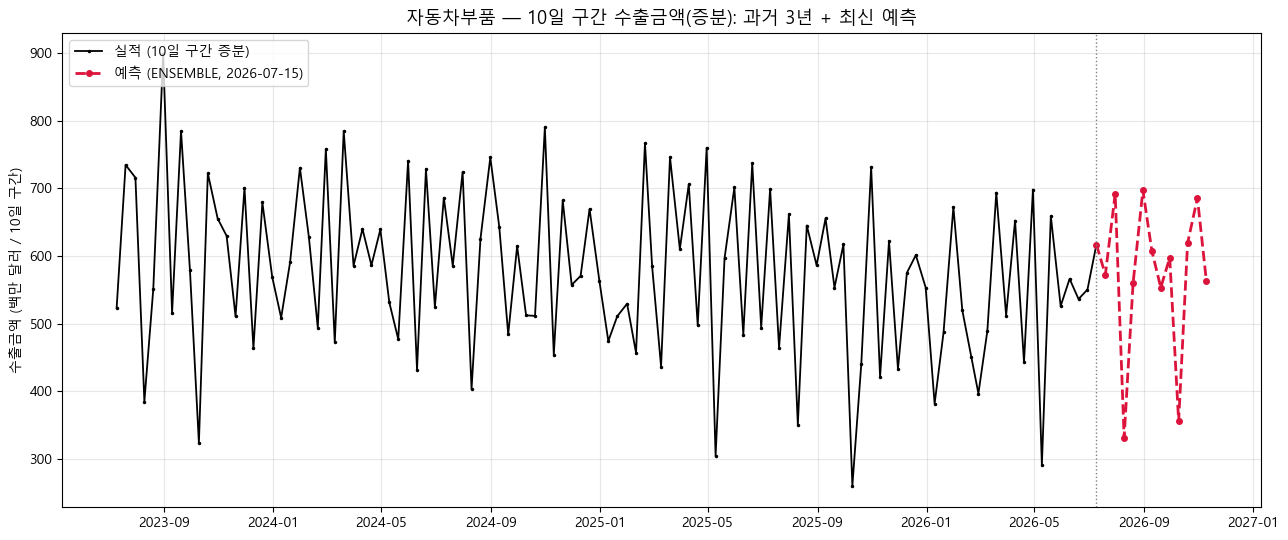

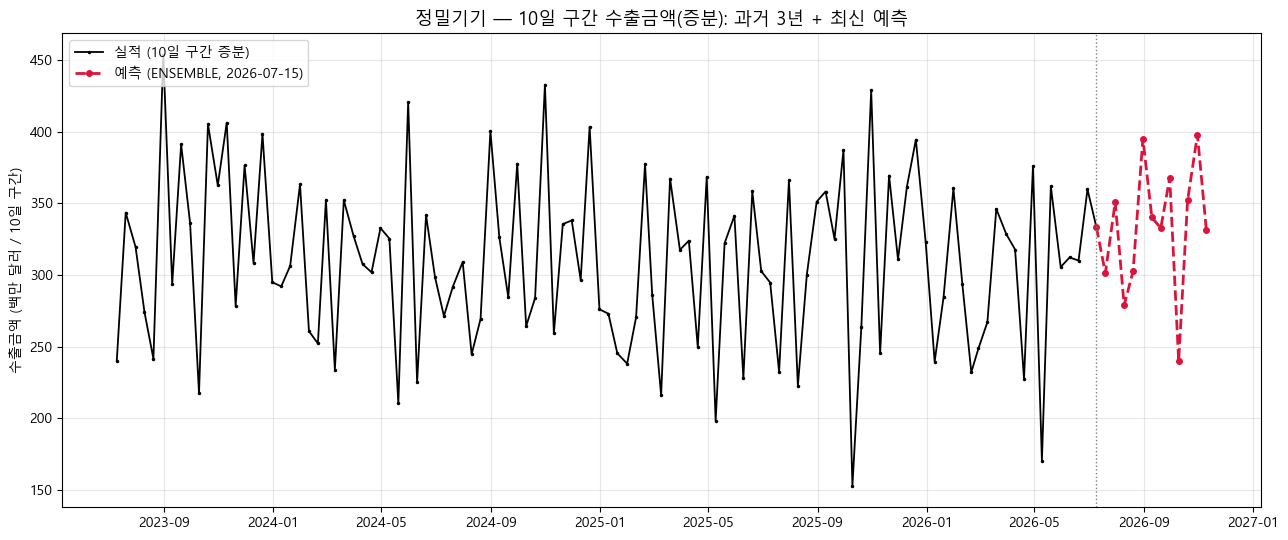

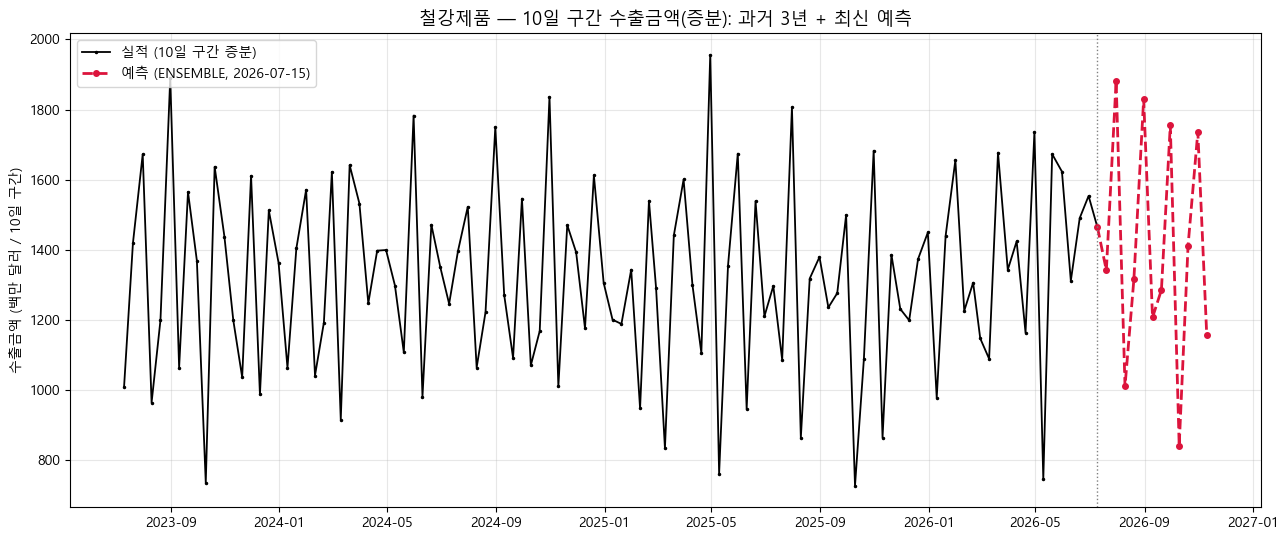

In [8]:
def plot_item_detail(item_name: str, years_back: int = PLOT_YEARS_BACK,
                     model: str = MODEL, show_all_models: bool = SHOW_ALL_MODELS):
    """품목 1개 상세: 과거 years_back년 실적(실선) + 최신 예측(점선)"""
    s = load_actual_series(item_name)
    if s.empty:
        print(f"{item_name}: 실적 데이터 없음"); return
    s_plot = s[s.index >= s.index[-1] - pd.DateOffset(years=years_back)]

    fd_latest = latest_forecast_date(item_name)
    fig, ax = plt.subplots(figsize=(13, 5.5))
    # 실제치: 실선
    ax.plot(s_plot.index, s_plot.values / 1000, color="black", lw=1.3,
            marker=".", ms=3, label="실적 (10일 구간 증분)")
    # 예측치: 점선
    if fd_latest:
        fdf_all = load_forecast(item_name, fd_latest,
                                model=None if show_all_models else model)
        if not fdf_all.empty:
            bridge_x, bridge_y = s.index[-1], s.values[-1] / 1000
            for m_, g in fdf_all.groupby("model"):
                if m_ == model:
                    ax.plot([bridge_x] + list(g["target_date"]),
                            [bridge_y] + list(g["exp_dlr"] / 1000),
                            color="crimson", lw=2.0, ls="--", marker="o", ms=4,
                            label=f"예측 ({m_}, {fd_latest})")
                elif show_all_models:
                    ax.plot([bridge_x] + list(g["target_date"]),
                            [bridge_y] + list(g["exp_dlr"] / 1000),
                            ls="--", lw=1.0, alpha=0.5, label=f"예측 ({m_})")
            ax.axvline(s.index[-1], color="gray", ls=":", lw=1)
    else:
        print(f"{item_name}: 저장된 예측 없음 — 실적만 표시")

    ax.set_title(f"{item_name} — 10일 구간 수출금액(증분): 과거 {years_back}년 + 최신 예측",
                 fontsize=13)
    ax.set_ylabel("수출금액 (백만 달러 / 10일 구간)")
    ax.legend(loc="upper left")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# ---- 실행: 선택 품목 전체 상세 차트 ----
for _it in SELECTED_ITEMS:
    plot_item_detail(_it)


### 5-3. 분석 요약표 (최근 실적 모멘텀 + 예측 증가율)

In [ ]:
def build_summary_table(items: List[str], model: str = MODEL) -> pd.DataFrame:
    """
    품목별 분석 요약:
      - 최근 3구간(≈30일) 실적 합 vs 전년 동기간(36구간 전) 합 → YoY
      - 최신 예측 12구간 합 vs 직전 실적 12구간 합 → 예측 증감률
      - 예측 12구간 합 vs 전년 동기(실적) 12구간 합 → 예측 YoY
    단위: 백만 달러
    """
    fd_latest = latest_forecast_date()
    rows = []
    for item in items:
        s = load_actual_series(item)
        if s.empty:
            continue
        r = {"품목": item, "최근구간": s.index[-1].date()}

        # 최근 3구간 합 및 YoY (연간 36구간 오프셋)
        if len(s) >= 39:
            cur3, prev3 = s.iloc[-3:].sum(), s.iloc[-39:-36].sum()
            r["최근30일(백만$)"] = round(cur3 / 1000, 0)
            r["최근30일 YoY(%)"] = round((cur3 / prev3 - 1) * 100, 1) if prev3 else np.nan

        # 최신 예측 12구간 합
        fdf = load_forecast(item, fd_latest, model=model) if fd_latest else pd.DataFrame()
        if not fdf.empty:
            fsum = fdf["exp_dlr"].sum()
            r["예측120일합(백만$)"] = round(fsum / 1000, 0)
            if len(s) >= 12:
                prev12 = s.iloc[-12:].sum()
                r["직전120일 대비(%)"] = round((fsum / prev12 - 1) * 100, 1) if prev12 else np.nan
            # 예측 YoY: 미래 12구간(N+1~N+12)의 전년 동기 = 36구간 전 = N-35~N-24 = iloc[-36:-24]
            if len(s) >= 36:
                yoy_base = s.iloc[-36:-24].sum()
                r["예측 YoY(%)"] = round((fsum / yoy_base - 1) * 100, 1) if yoy_base else np.nan
        rows.append(r)
    df = pd.DataFrame(rows)
    return df

df_summary = build_summary_table(SELECTED_ITEMS)
print(f"분석 요약 (예측 모델: {MODEL}, 최신 빈티지: {latest_forecast_date()})")
df_summary


## 6. ③ 예측일 2개 입력 → 예측치 변화/차이 분석

`FORECAST_DATE_A`(이전) vs `FORECAST_DATE_B`(최신) 두 빈티지의 예측을 비교합니다.
- 6-1: 비교 대상 날짜 확정 (None이면 최신 2개 자동)
- 6-2: 품목별 오버레이 차트 — **실적 실선 / 두 빈티지 예측 점선**
- 6-3: 공통 target_date 기준 차이표 + 변화 요약표

### 6-1. 비교 대상 예측일 확정

In [ ]:
def resolve_vintage_pair(fd_a, fd_b, model: str = MODEL):
    """
    비교할 두 forecast_date 확정.
      - 둘 다 None: DB 최신 2개 자동 (A=이전, B=최신)
      - 문자열/날짜 입력: DB 존재 검증
    """
    avail = pd.read_sql(text(f"""
        SELECT DISTINCT forecast_date FROM {FORECAST_TABLE}
        WHERE model = :model ORDER BY forecast_date
    """), engine, params={"model": model})
    avail_dates = pd.to_datetime(avail["forecast_date"]).dt.date.tolist()
    if len(avail_dates) == 0:
        raise ValueError(f"모델 {model}의 저장된 예측이 없습니다.")

    def _parse(x):
        return pd.to_datetime(x).date() if x is not None else None

    a, b = _parse(fd_a), _parse(fd_b)
    if a is None and b is None:
        if len(avail_dates) < 2:
            raise ValueError(f"빈티지가 1개뿐이라 비교 불가. 저장된 예측일: {avail_dates}")
        a, b = avail_dates[-2], avail_dates[-1]
        print(f"[자동 선택] 최신 2개 빈티지 사용")
    else:
        if a is None or b is None:
            raise ValueError("FORECAST_DATE_A/B는 둘 다 지정하거나 둘 다 None이어야 합니다.")
        for x in (a, b):
            if x not in avail_dates:
                raise ValueError(f"{x}는 저장된 예측일이 아닙니다.\n사용 가능: {avail_dates}")
    if a > b:
        a, b = b, a
        print("[주의] A > B 입력 → 순서 교환 (A=이전, B=최신)")
    print(f"비교 대상: A(이전) = {a}  |  B(최신) = {b}  |  모델 = {model}")
    return a, b

VINT_A, VINT_B = resolve_vintage_pair(FORECAST_DATE_A, FORECAST_DATE_B)


### 6-2. 품목별 두 빈티지 오버레이 (실적 실선 / 예측 점선)

In [ ]:
def plot_vintage_pair(item_name: str, fd_a, fd_b, model: str = MODEL,
                      months_back: int = OVERVIEW_MONTHS):
    """실적(실선) + 빈티지 A(파랑 점선) + 빈티지 B(빨강 점선)"""
    s = load_actual_series(item_name)
    if s.empty:
        print(f"{item_name}: 실적 데이터 없음"); return
    s_plot = s[s.index >= s.index[-1] - pd.DateOffset(months=months_back)]

    fa = load_forecast(item_name, fd_a, model=model)
    fb = load_forecast(item_name, fd_b, model=model)
    if fa.empty and fb.empty:
        print(f"{item_name}: 두 빈티지 모두 예측 없음 — 생략"); return

    fig, ax = plt.subplots(figsize=(13, 5.5))
    # 실제치: 검은 실선
    ax.plot(s_plot.index, s_plot.values / 1000, color="black", lw=1.6,
            marker=".", ms=4, label="실적 (10일 구간 증분)", zorder=5)
    # 예측치: 점선 2개
    if not fa.empty:
        ax.plot(fa["target_date"], fa["exp_dlr"] / 1000, color="royalblue",
                lw=1.8, ls="--", marker="s", ms=4, alpha=0.85,
                label=f"예측 A ({fd_a})")
    if not fb.empty:
        ax.plot(fb["target_date"], fb["exp_dlr"] / 1000, color="crimson",
                lw=2.0, ls="--", marker="o", ms=4,
                label=f"예측 B ({fd_b})")
    ax.axvline(s.index[-1], color="gray", ls=":", lw=1)

    ax.set_title(f"{item_name} — 예측 빈티지 비교 ({model}): {fd_a} vs {fd_b}", fontsize=13)
    ax.set_ylabel("수출금액 (백만 달러 / 10일 구간)")
    ax.legend(loc="upper left")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# ---- 실행: 선택 품목 전체 ----
for _it in SELECTED_ITEMS:
    plot_vintage_pair(_it, VINT_A, VINT_B)


### 6-3. 예측치 변화/차이 분석표
- **품목×구간 상세**: 공통 `target_date`에서 B − A 차이 및 변화율
- **품목별 요약**: 공통 구간 합계 기준 변화 — 예측 상향/하향 품목 정렬

In [ ]:
def vintage_diff_detail(item_name: str, fd_a, fd_b, model: str = MODEL) -> pd.DataFrame:
    """공통 target_date 기준 두 빈티지 예측 차이 (단위: 백만 달러)"""
    fa = load_forecast(item_name, fd_a, model=model).rename(columns={"exp_dlr": "A"})
    fb = load_forecast(item_name, fd_b, model=model).rename(columns={"exp_dlr": "B"})
    if fa.empty or fb.empty:
        return pd.DataFrame()
    m = fa[["target_date", "A"]].merge(fb[["target_date", "B"]], on="target_date", how="inner")
    if m.empty:
        return pd.DataFrame()
    m.insert(0, "품목", item_name)
    m["A(백만$)"]   = (m.pop("A") / 1000).round(0)
    m["B(백만$)"]   = (m.pop("B") / 1000).round(0)
    m["차이 B−A"]   = (m["B(백만$)"] - m["A(백만$)"]).round(0)
    m["변화율(%)"]  = np.where(m["A(백만$)"] != 0,
                               (m["차이 B−A"] / m["A(백만$)"] * 100).round(1), np.nan)
    m["target_date"] = m["target_date"].dt.date
    return m

def vintage_diff_summary(items: List[str], fd_a, fd_b, model: str = MODEL) -> pd.DataFrame:
    """품목별 공통 구간 합계 기준 예측치 변화 요약 (변화율 내림차순 정렬)"""
    rows = []
    for item in items:
        d = vintage_diff_detail(item, fd_a, fd_b, model=model)
        if d.empty:
            continue
        a_sum, b_sum = d["A(백만$)"].sum(), d["B(백만$)"].sum()
        rows.append({
            "품목": item,
            "공통구간수": len(d),
            f"A합 {fd_a}(백만$)": round(a_sum, 0),
            f"B합 {fd_b}(백만$)": round(b_sum, 0),
            "차이 B−A(백만$)": round(b_sum - a_sum, 0),
            "변화율(%)": round((b_sum / a_sum - 1) * 100, 1) if a_sum else np.nan,
        })
    df = pd.DataFrame(rows)
    if not df.empty:
        df = df.sort_values("변화율(%)", ascending=False).reset_index(drop=True)
    return df

# ---- 실행 ① 품목별 요약표 ----
df_diff_summary = vintage_diff_summary(SELECTED_ITEMS, VINT_A, VINT_B)
print(f"예측치 변화 요약 — 모델 {MODEL} | A={VINT_A} → B={VINT_B} (공통 target_date 합계 기준)")
df_diff_summary


In [ ]:
# ---- 실행 ② 변화율 막대 차트 ----
if not df_diff_summary.empty:
    fig, ax = plt.subplots(figsize=(11, 0.55 * len(df_diff_summary) + 1.5))
    colors = ["crimson" if v >= 0 else "royalblue" for v in df_diff_summary["변화율(%)"]]
    ax.barh(df_diff_summary["품목"], df_diff_summary["변화율(%)"], color=colors, alpha=0.85)
    for _, r in df_diff_summary.iterrows():
        ax.text(r["변화율(%)"], r["품목"], f' {r["변화율(%)"]:+.1f}%',
                va="center", ha="left" if r["변화율(%)"] >= 0 else "right", fontsize=9)
    ax.axvline(0, color="black", lw=0.8)
    ax.invert_yaxis()
    ax.set_title(f"예측치 변화율 (%) — {MODEL}: {VINT_A} → {VINT_B} (공통 구간 합계 기준)",
                 fontsize=12)
    ax.grid(alpha=0.3, axis="x")
    plt.tight_layout()
    plt.show()
else:
    print("비교 가능한 공통 구간이 없습니다.")


In [ ]:
# ---- 실행 ③ 품목×구간 상세 차이표 (전체 품목 통합) ----
_details = [vintage_diff_detail(it, VINT_A, VINT_B) for it in SELECTED_ITEMS]
df_diff_detail = pd.concat([d for d in _details if not d.empty], ignore_index=True) \
    if any(not d.empty for d in _details) else pd.DataFrame()
print(f"품목×구간 상세 차이 ({len(df_diff_detail)}행) — 단위: 백만 달러")
df_diff_detail


## 7. 개별 실행 예시 (필요 시 품목명/날짜만 바꿔 사용)

In [ ]:
# 예측 수행일 조회 (특정 품목/모델 기준)
# list_forecast_dates(item_name="반도체", model="ENSEMBLE")

# 개별 품목 상세 (실적 실선 + 최신 예측 점선, 전체 모델 표시)
# plot_item_detail("반도체", years_back=5, show_all_models=True)

# 특정 두 예측일 직접 비교
# plot_vintage_pair("반도체", "2026-07-01", "2026-07-11")
# vintage_diff_detail("반도체", "2026-07-01", "2026-07-11")
